# Sistema 6G – Processamento de Sinais IQ e Pré-Distorção Digital com VARMAX

> Notebook Simplificado, Com inserção de Lags e não linearidades, Automatizado.

## Bloco 1 - Importações e Carga de Dados

In [1]:
from pathlib import Path
from itertools import combinations_with_replacement
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VARMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
%matplotlib inline

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
plt.style.use('dark_background')

In [22]:
# ── Configuração global
DATA_FILE      = "dadosIniciais.xlsx"                    # Define o nome do arquivo com o DataFrame em Excel
DATA_PATH      = Path.cwd() / DATA_FILE                  # Constrói o path absoluto para o arquivo de dados
ENDOG_COLS     = ['Yreal', 'Yimg']
EXOG_BASE      = ['Xreal', 'Ximg']                       # colunas originais do exógeno
TRAIN_FRAC     = 0.6
VAL_FRAC       = 0.2
MAX_LAG_SEARCH = 1                                       # para o grid search
N_LAGS         = 3
GRAU           = 2

## Bloco 02 - Carregamento e Validação de Dados

In [3]:
from pathlib import Path                            # Construção de Path
data_file = "dadosIniciais.xlsx"                    # Define o nome do arquivo com o DataFrame em Excel

DATA_PATH = Path.cwd() / data_file                  # Constrói o path absoluto para o arquivo de dados

data = pd.read_excel(DATA_PATH, engine="openpyxl")  # Lê o dataframe com o openpyxl, para arquivos .xlsx
print(f"Shape: {data.shape}")                       # Retorna uma tupla (linhas, colunas)
print(f"NaNs por coluna:\n{data.isna().sum()}")     # Retorna a soma de valores NaNs (faltantes) por coluna
assert data.shape[1] >= 4,\
    "Esperadas pelo menos 4 colunas (Xreal, Ximg, Yreal, Yimg)" # verifica se o DataFrame possui pelo menos 4 colunas.

Shape: (48383, 4)
NaNs por coluna:
 1.137157     0
-0.061341     0
 26.208588    0
-1.858761     0
dtype: int64


In [4]:
df_input  = pd.DataFrame(data.iloc[:, :2].values, columns=EXOG_BASE)   # I/Q de entrada
df_output = pd.DataFrame(data.iloc[:, 2:4].values, columns=ENDOG_COLS) # I/Q de saída

df_concat = (pd.concat([df_input, df_output], axis=1).reset_index(drop=True))  # concatena horizontalmente


print(f"Shape: {df_concat.shape}")
print(f"Colunas: {df_concat.columns.tolist()}")
df_concat.head()

Shape: (48383, 4)
Colunas: ['Xreal', 'Ximg', 'Yreal', 'Yimg']


,Xreal,Ximg,Yreal,Yimg
0,1.137499,0.082685,26.244322,1.471061
1,1.117805,0.225745,25.818823,4.754794
2,1.078412,0.365120,24.978243,8.000349
3,1.020086,0.498130,23.716368,11.057279
4,0.944010,0.622210,22.005617,13.972568


## Bloco 03 - Análise Exploratória

In [10]:
CORES = {
    "entrada":  "#2196F3",   # azul
    "saida":    "#f44336",   # vermelho
    "previsto": "#FF9800",   # laranja
    "ideal":    "#4CAF50",   # verde
}
GRID_STYLE = {"linestyle": "--", "alpha": 0.5}

In [15]:
# ── Seção 3: Funções de EDA ───────────────────────────────────────────────────
def calcula_magnitude_db(df, col_real, col_img):
    """Calcula magnitude do sinal IQ em dB."""
    mag = np.sqrt(df[col_real]**2 + df[col_img]**2)
    return 20 * np.log10(mag)


def plot_amam(df_concat):
    """Gráfico AM/AM: magnitude de entrada vs saída em dB."""
    mag_in  = calcula_magnitude_db(df_concat, 'Xreal', 'Ximg')
    mag_out = calcula_magnitude_db(df_concat, 'Yreal', 'Yimg')

    plt.figure(figsize=(16, 8))
    plt.plot(mag_in, mag_out, '.', markersize=2,
             color=CORES["entrada"], alpha=0.5)
    plt.xlabel("Entrada (dBFS)")
    plt.ylabel("Saída (dBFS)")
    plt.title("Curva AM/AM", fontsize=14, fontweight='bold')
    plt.grid(True, **GRID_STYLE)
    plt.tight_layout()
    plt.show()


def plot_series(df_concat):
    """
    Plota magnitude de entrada e saída:
      - Subplots lado a lado
      - Sobrepostos no mesmo gráfico para comparação
    """
    mag_in  = calcula_magnitude_db(df_concat, 'Xreal', 'Ximg')
    mag_out = calcula_magnitude_db(df_concat, 'Yreal', 'Yimg')

    # 1. Subplots lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(mag_in.values, color=CORES["entrada"], linewidth=0.8)
    axes[0].set_title('Série Temporal — ENTRADA', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Amostra (tempo)')
    axes[0].set_ylabel('Magnitude (dB)')
    axes[0].grid(True, **GRID_STYLE)

    axes[1].plot(mag_out.values, color=CORES["saida"], linewidth=0.8)
    axes[1].set_title('Série Temporal — SAÍDA', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Amostra (tempo)')
    axes[1].set_ylabel('Magnitude (dB)')
    axes[1].grid(True, **GRID_STYLE)

    plt.tight_layout()
    plt.show()

    # 2. Sobrepostos para comparação direta
    plt.figure(figsize=(15, 6))
    plt.plot(mag_in.values,  label='Entrada (dB)',
             color=CORES["entrada"], linewidth=0.8, alpha=0.8)
    plt.plot(mag_out.values, label='Saída (dB)',
             color=CORES["saida"],   linewidth=0.8, alpha=0.8)
    plt.xlabel('Amostra (tempo)')
    plt.ylabel('Magnitude (dB)')
    plt.title('Comparação: Entrada vs Saída ao longo do Tempo',
              fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, **GRID_STYLE)
    plt.tight_layout()
    plt.show()


def testa_estacionariedade(df, colunas):
    """Roda ADF e KPSS para cada coluna e imprime resultado."""
    from statsmodels.tsa.stattools import adfuller, kpss
    print(f"{'Coluna':>8} | {'ADF p':>8} | {'Status ADF':^22} | "
          f"{'KPSS p':>8} | {'Status KPSS':^22}")
    print("-" * 80)
    for col in colunas:
        serie     = df[col]
        adf_p     = adfuller(serie)[1]
        kpss_p    = kpss(serie)[1]
        st_adf    = "estacionária" if adf_p  < 0.05 else "não estacionária"
        st_kpss   = "estacionária" if kpss_p > 0.05 else "não estacionária"
        print(f"{col:>8} | {adf_p:>8.4f} | {st_adf:^22} | "
              f"{kpss_p:>8.4f} | {st_kpss:^22}")


def plot_acf_pacf(df_input, df_output, lags=50, dark_mode=True, figsize=(16, 16)):
    """
    Plota ACF e PACF para todos os sinais de entrada e saída.
    :param df_input:   DataFrame com colunas Xreal e Ximg
    :param df_output:  DataFrame com colunas Yreal e Yimg
    :param lags:       número de lags a plotar
    :param dark_mode:  True para fundo escuro, False para fundo claro
    :param figsize:    tamanho da figura
    """
    if dark_mode:
        plt.style.use('dark_background')
        text_color = 'white'
    else:
        plt.style.use('default')
        text_color = 'black'

    config = [
        {"data": df_input["Xreal"],   "nome": "Entrada Real (Xreal)",       "cor": "#2196F3"},
        {"data": df_input["Ximg"],    "nome": "Entrada Imaginária (Ximg)",   "cor": "#64B5F6"},
        {"data": df_output["Yreal"],  "nome": "Saída Real (Yreal)",          "cor": "#f44336"},
        {"data": df_output["Yimg"],   "nome": "Saída Imaginária (Yimg)",     "cor": "#FF8A80"},
    ]

    fig, axes = plt.subplots(len(config), 2, figsize=figsize)

    for i, cfg in enumerate(config):

        # ACF — coluna esquerda
        plot_acf(cfg["data"], lags=lags, ax=axes[i, 0],
                 color=cfg["cor"],
                 vlines_kwargs={"color": cfg["cor"]})
        axes[i, 0].set_title(f'ACF — {cfg["nome"]}',
                              fontsize=12, fontweight='bold', color=text_color)
        axes[i, 0].set_xlabel('Lags', color=text_color)
        axes[i, 0].set_ylabel('Autocorrelação', color=text_color)
        axes[i, 0].grid(True, **GRID_STYLE)

        # PACF — coluna direita
        plot_pacf(cfg["data"], lags=lags, ax=axes[i, 1],
                  color=cfg["cor"],
                  vlines_kwargs={"color": cfg["cor"]})
        axes[i, 1].set_title(f'PACF — {cfg["nome"]}',
                              fontsize=12, fontweight='bold', color=text_color)
        axes[i, 1].set_xlabel('Lags', color=text_color)
        axes[i, 1].set_ylabel('Autocorrelação Parcial', color=text_color)
        axes[i, 1].grid(True, **GRID_STYLE)

    plt.suptitle(
        'Análise de Autocorrelação (ACF) e Autocorrelação Parcial (PACF)',
        fontsize=16, fontweight='bold', color=text_color, y=1.02
    )
    plt.tight_layout()
    plt.show()
    plt.style.use('default')   # restaura estilo padrão após o plot

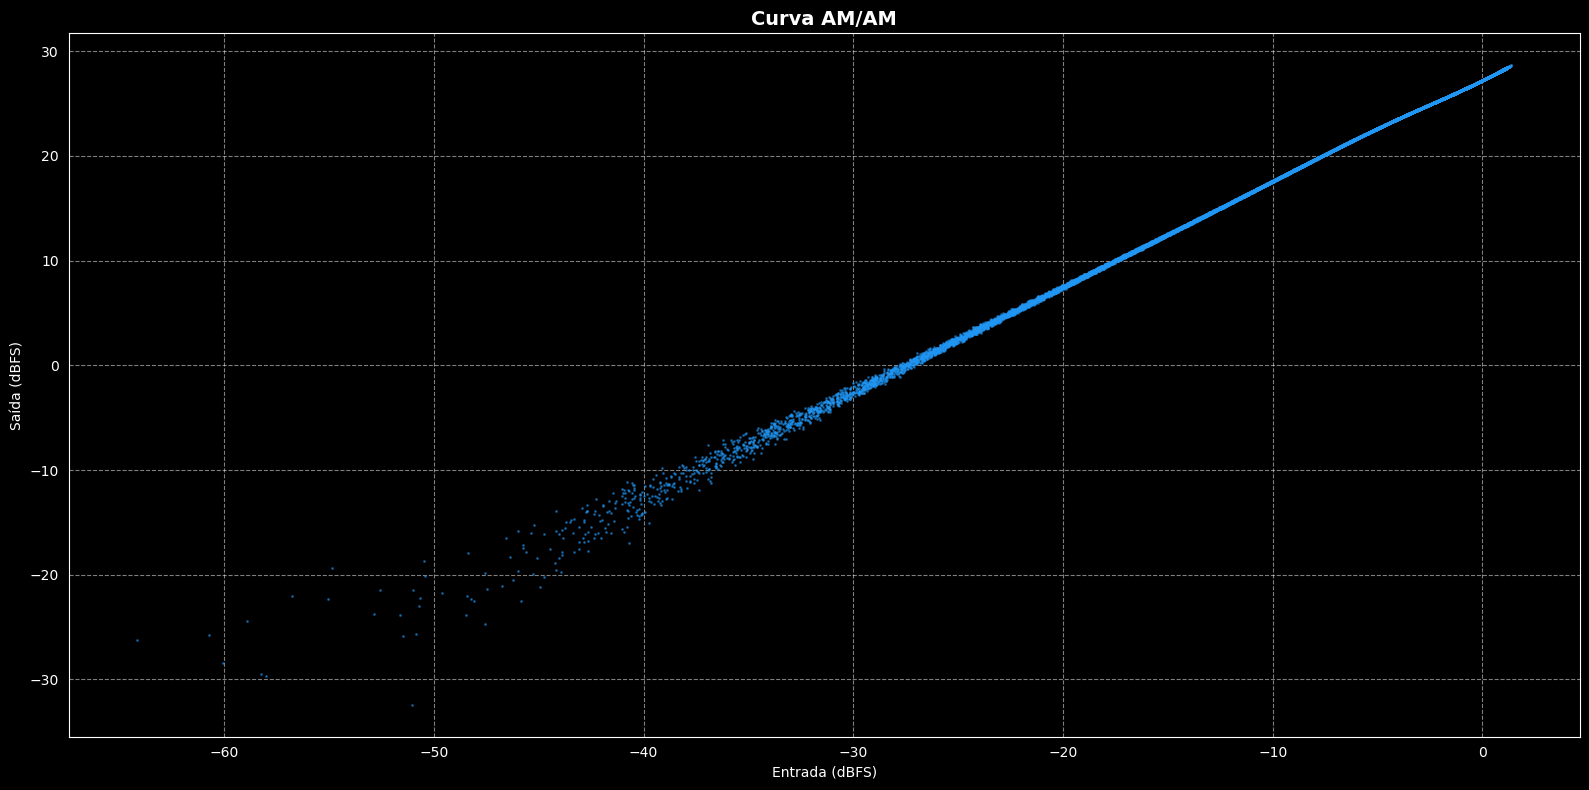

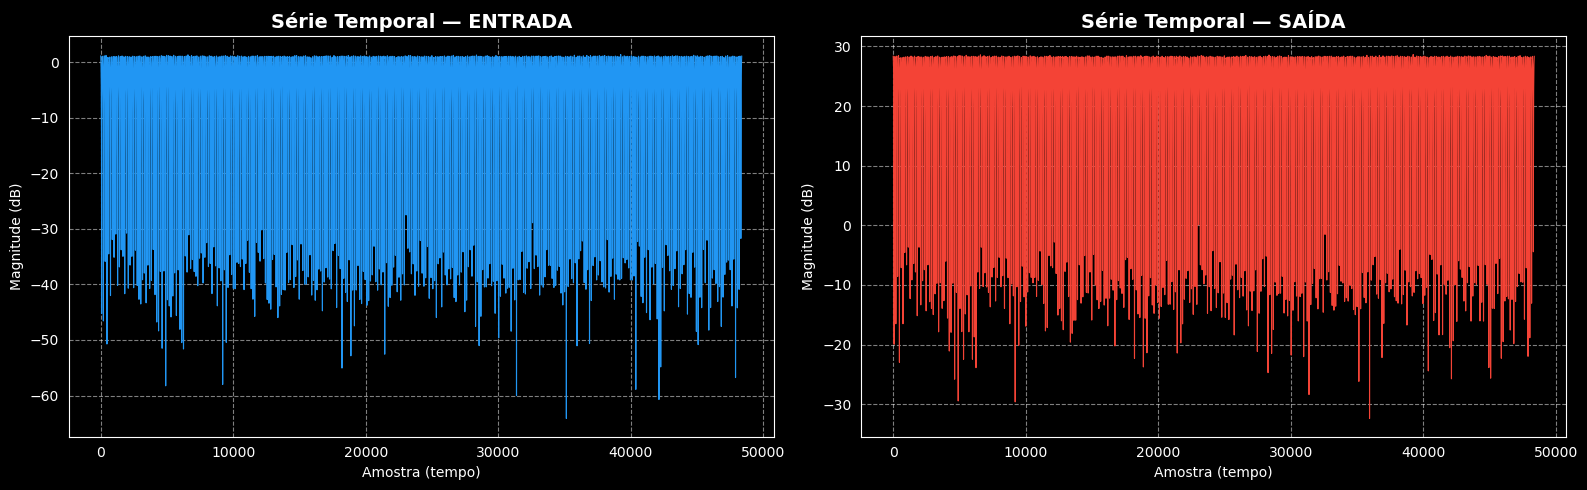

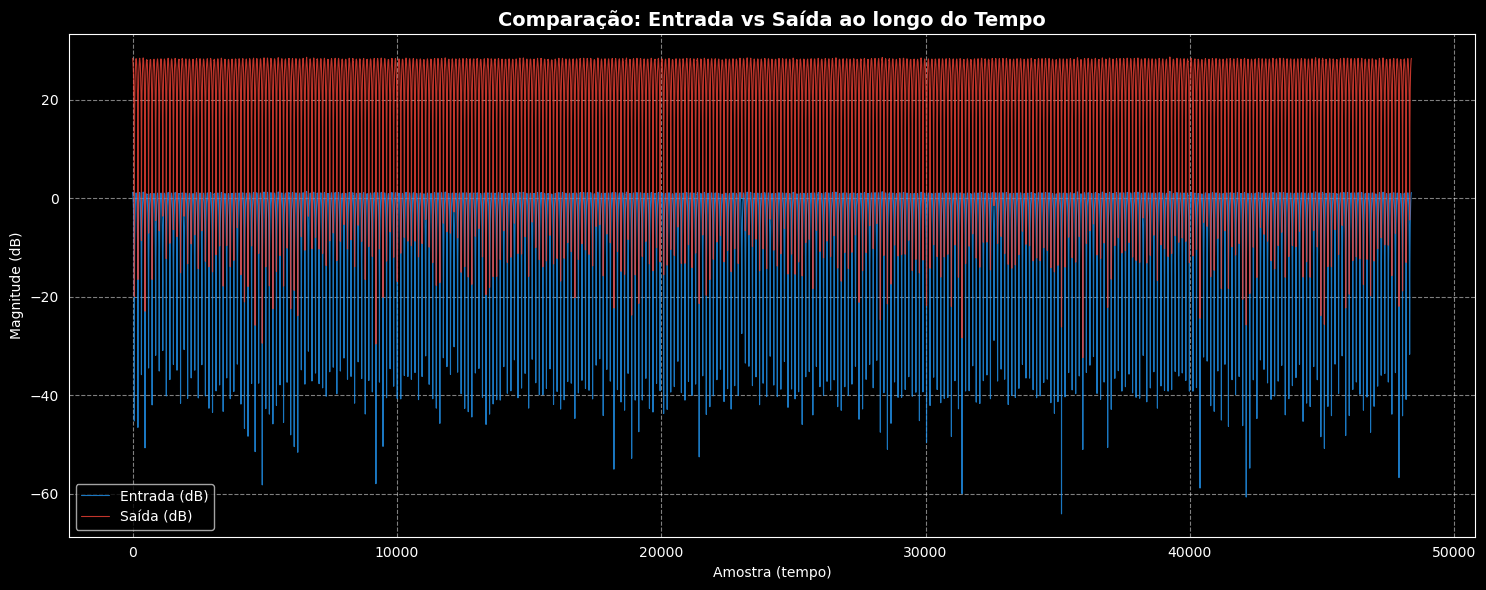

  Coluna |    ADF p |       Status ADF       |   KPSS p |      Status KPSS      
--------------------------------------------------------------------------------
   Yreal |   0.0000 |      estacionária      |   0.1000 |      estacionária     
    Yimg |   0.0000 |      estacionária      |   0.1000 |      estacionária     
   Xreal |   0.0000 |      estacionária      |   0.1000 |      estacionária     
    Ximg |   0.0000 |      estacionária      |   0.1000 |      estacionária     


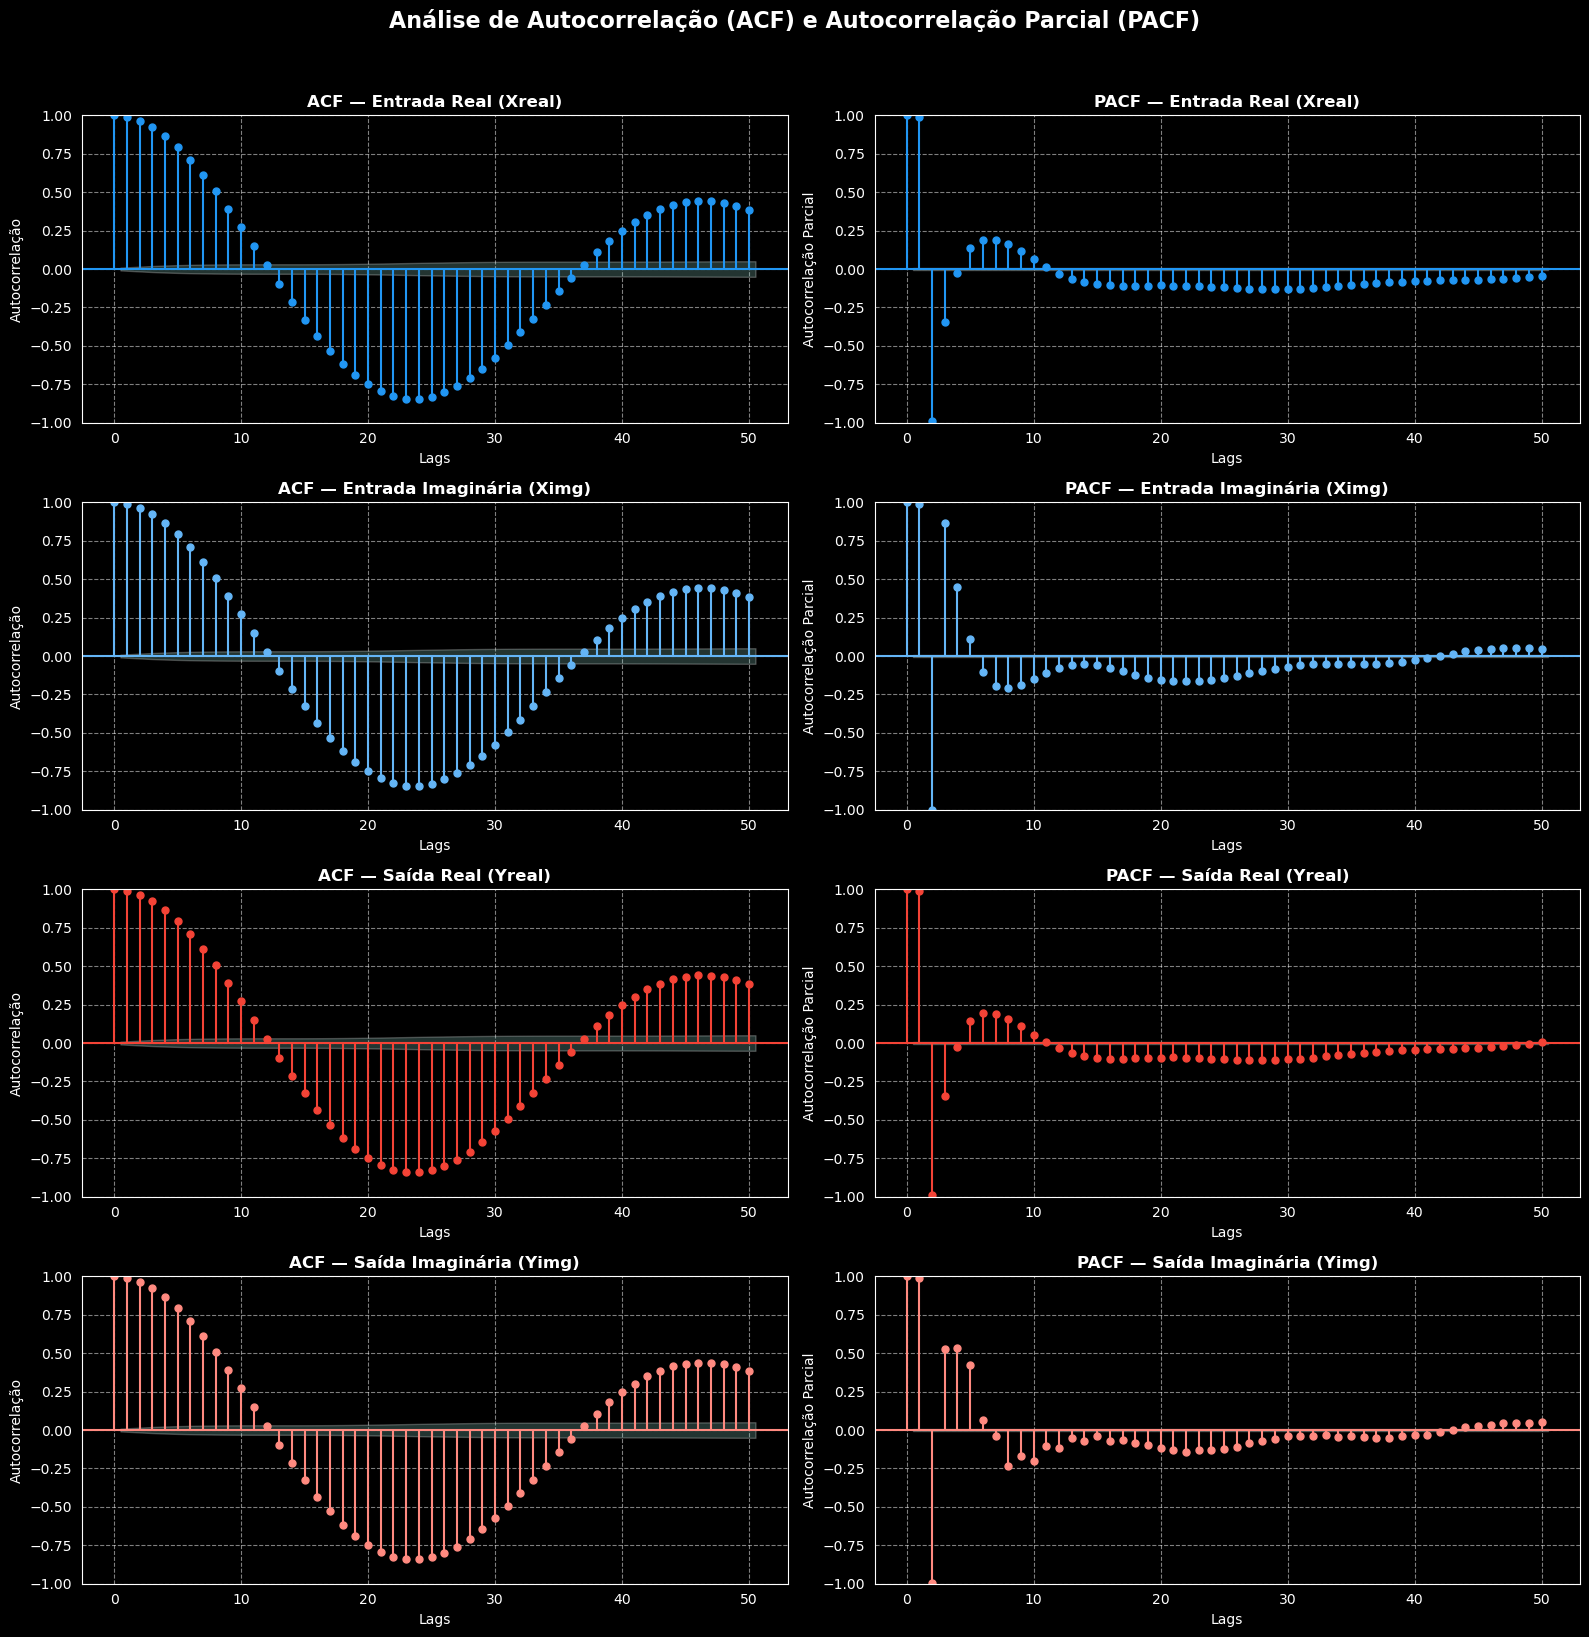

In [16]:
plot_amam(df_concat)
plot_series(df_concat)
testa_estacionariedade(df_concat, ENDOG_COLS + EXOG_BASE)
plot_acf_pacf(df_input, df_output, lags=50)

## Bloco 04 - Engenharia de Features

### Automação de Inserção de Lags

In [17]:
def criar_lags(df, colunas, n_lags):
    """
    Recebe um DataFrame, uma lista de colunas e um número de lags.
    :param df     : pd.DataFrame -> Original
    :param colunas: Lista        -> Nomes de colunas, ex: ['Xreal', 'Ximg']
    :param n_lags : Inteiro      -> Número de lags a criar (1 até o n_lags)
    :return       : Novo DataFrame com as colunas originais + as colunas de lag.
    """
    df_novo = df.copy()

    for coluna in colunas:
        for k in range(1, n_lags + 1):
            df_novo[f'{coluna}_lag{k}'] = df_novo[coluna].shift(k)
    return df_novo

### Inserção de Termos Não Lineares

Modelagem do PA ideal, com ganho linear: $Y(t) = G_{anho}\cdot X(t)$ <br>
Modelagem do PA mais próxima do real, com distorção introduzida: $Y(t) = a_1\cdot X(t) \:+\: a_2\cdot X^2(t) \:+\: a_3\cdot X^3(t)\: + \:...$

In [18]:
def criar_termos_polinomiais(df, colunas, grau=2):
    """
    :param df: DataFrame com as colunas (com lags)
    :param colunas: lista de colunas a combinar ex: ['Xreal', 'Ximg', 'Xreal_lag1']
    :param grau: grau máximo do polinômio
    :return: DataFrame com novos termos não lineares adicionados
    """
    df_novo = df.copy()

    for par in combinations_with_replacement(colunas, grau):
        nome = '_x_'.join(par)
        df_novo[nome] = np.multiply.reduce([df_novo[coluna] for coluna in par])
    return df_novo

In [19]:
# Lags das variáveis exógenas
df_features = criar_lags(df_concat, EXOG_BASE, n_lags=N_LAGS)

# Termos não lineares sobre todas as colunas exógenas (originais + lags)
colunas_exog = [c for c in df_features.columns if c not in ENDOG_COLS]
df_features  = criar_termos_polinomiais(df_features, colunas_exog, grau=GRAU)

# Remove NaNs gerados pelo shift
df_features = df_features.dropna().reset_index(drop=True)

# Lista dinâmica de exógenas para o VARMAX
EXOG_COLS = [c for c in df_features.columns if c not in ENDOG_COLS]

print(f"Total de features exógenas: {len(EXOG_COLS)}")
print(f"Features: {EXOG_COLS}")
df_features.head()

Total de features exógenas: 44
Features: ['Xreal', 'Ximg', 'Xreal_lag1', 'Xreal_lag2', 'Xreal_lag3', 'Ximg_lag1', 'Ximg_lag2', 'Ximg_lag3', 'Xreal_x_Xreal', 'Xreal_x_Ximg', 'Xreal_x_Xreal_lag1', 'Xreal_x_Xreal_lag2', 'Xreal_x_Xreal_lag3', 'Xreal_x_Ximg_lag1', 'Xreal_x_Ximg_lag2', 'Xreal_x_Ximg_lag3', 'Ximg_x_Ximg', 'Ximg_x_Xreal_lag1', 'Ximg_x_Xreal_lag2', 'Ximg_x_Xreal_lag3', 'Ximg_x_Ximg_lag1', 'Ximg_x_Ximg_lag2', 'Ximg_x_Ximg_lag3', 'Xreal_lag1_x_Xreal_lag1', 'Xreal_lag1_x_Xreal_lag2', 'Xreal_lag1_x_Xreal_lag3', 'Xreal_lag1_x_Ximg_lag1', 'Xreal_lag1_x_Ximg_lag2', 'Xreal_lag1_x_Ximg_lag3', 'Xreal_lag2_x_Xreal_lag2', 'Xreal_lag2_x_Xreal_lag3', 'Xreal_lag2_x_Ximg_lag1', 'Xreal_lag2_x_Ximg_lag2', 'Xreal_lag2_x_Ximg_lag3', 'Xreal_lag3_x_Xreal_lag3', 'Xreal_lag3_x_Ximg_lag1', 'Xreal_lag3_x_Ximg_lag2', 'Xreal_lag3_x_Ximg_lag3', 'Ximg_lag1_x_Ximg_lag1', 'Ximg_lag1_x_Ximg_lag2', 'Ximg_lag1_x_Ximg_lag3', 'Ximg_lag2_x_Ximg_lag2', 'Ximg_lag2_x_Ximg_lag3', 'Ximg_lag3_x_Ximg_lag3']


,Xreal,Ximg,Yreal,Yimg,Xreal_lag1,Xreal_lag2,Xreal_lag3,Ximg_lag1,Ximg_lag2,Ximg_lag3,...,Xreal_lag3_x_Xreal_lag3,Xreal_lag3_x_Ximg_lag1,Xreal_lag3_x_Ximg_lag2,Xreal_lag3_x_Ximg_lag3,Ximg_lag1_x_Ximg_lag1,Ximg_lag1_x_Ximg_lag2,Ximg_lag1_x_Ximg_lag3,Ximg_lag2_x_Ximg_lag2,Ximg_lag2_x_Ximg_lag3,Ximg_lag3_x_Ximg_lag3
0,1.020086,0.498130,23.716368,11.057279,1.078412,1.117805,1.137499,0.365120,0.225745,0.082685,...,1.293904,0.415324,0.256785,0.094054,0.133313,0.082424,0.030190,0.050961,0.018666,0.006837
1,0.944010,0.622210,22.005617,13.972568,1.020086,1.078412,1.117805,0.498130,0.365120,0.225745,...,1.249489,0.556813,0.408133,0.252339,0.248134,0.181877,0.112451,0.133313,0.082424,0.050961
2,0.851759,0.734975,19.923262,16.563114,0.944010,1.020086,1.078412,0.622210,0.498130,0.365120,...,1.162973,0.670999,0.537190,0.393750,0.387146,0.309942,0.227181,0.248134,0.181877,0.133313
3,0.745220,0.834302,17.485760,18.874990,0.851759,0.944010,1.020086,0.734975,0.622210,0.498130,...,1.040576,0.749738,0.634708,0.508136,0.540188,0.457309,0.366113,0.387146,0.309942,0.248134
4,0.626634,0.918352,14.833193,20.853607,0.745220,0.851759,0.944010,0.834302,0.734975,0.622210,...,0.891154,0.787590,0.693823,0.587373,0.696061,0.613191,0.519112,0.540188,0.457309,0.387146


## Bloco 05 - Divisão Treino | Teste | Validação

In [20]:
n         = len(df_features)
train_end = int(n * TRAIN_FRAC)
val_end   = int(n * (TRAIN_FRAC + VAL_FRAC))

train = df_features.iloc[:train_end].reset_index(drop=True)
val   = df_features.iloc[train_end:val_end].reset_index(drop=True)
test  = df_features.iloc[val_end:].reset_index(drop=True)

print(f"Treino:    {len(train):>5} amostras")
print(f"Validação: {len(val):>5} amostras")
print(f"Teste:     {len(test):>5} amostras")

Treino:    29028 amostras
Validação:  9676 amostras
Teste:      9676 amostras


## Bloco 06 - Otimização de Hiperparâmetros

### Otimização 01 - Via GridSearch

In [23]:
def grid_search_lag(train, val, endog_cols, exog_cols, max_lag=MAX_LAG_SEARCH, verbose=True):
    """
    Busca o melhor número de lags autorregressivos para o VARMAX.
    :param train:      DataFrame de treino
    :param val:        DataFrame de validação
    :param endog_cols: lista de colunas endógenas ex: ['Yreal', 'Yimg']
    :param exog_cols:  lista de colunas exógenas
    :param max_lag:    número máximo de lags a testar
    :param verbose:    imprime progresso
    :return:           dicionário com resultados e melhor lag
    """
    endog_train = train[endog_cols]
    exog_train  = train[exog_cols]
    endog_val   = val[endog_cols]
    exog_val    = val[exog_cols]

    resultados = {}

    for lag in range(1, max_lag + 1):
        try:
            modelo = VARMAX(endog_train, exog=exog_train, order=(lag, 0))
            res    = modelo.fit(disp=False, maxiter=500)

            # Previsão no conjunto de validação
            forecast = res.forecast(steps=len(endog_val), exog=exog_val)
            forecast.index = endog_val.index

            # RMSE médio entre todas as variáveis endógenas
            rmse_por_col = [
                np.sqrt(mean_squared_error(endog_val[col], forecast[col]))
                for col in endog_cols
            ]
            rmse_medio = np.mean(rmse_por_col)
            resultados[lag] = rmse_medio

            if verbose:
                print(f"  lag={lag:>2} | RMSE val = {rmse_medio:.6f}")

        except Exception as e:
            if verbose:
                print(f"  lag={lag:>2} | ERRO: {e}")
            resultados[lag] = np.inf

    melhor_lag = min(resultados, key=resultados.get)

    if verbose:
        print(f"\nMelhor lag: {melhor_lag} (RMSE val = {resultados[melhor_lag]:.6f})")

    return {"resultados": resultados, "melhor_lag": melhor_lag}

In [28]:
print("Buscando melhor número de lags autorregressivos...\n")
busca = grid_search_lag(train, val, ENDOG_COLS, EXOG_COLS)

MELHOR_LAG = busca["melhor_lag"]
print(f"\nLag escolhido para o modelo final: {MELHOR_LAG}")

Buscando melhor número de lags autorregressivos...



KeyboardInterrupt: 

In [27]:
lags  = list(busca["resultados"].keys())
rmses = list(busca["resultados"].values())

plt.figure(figsize=(10, 4))
plt.plot(lags, rmses, marker='o')
plt.axvline(MELHOR_LAG, color='red', linestyle='--', label=f"Melhor lag = {MELHOR_LAG}")
plt.xlabel("Número de lags")
plt.ylabel("RMSE (validação)")
plt.title("Grid Search — RMSE por número de lags")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'busca' is not defined

## Bloco 07 - Treinamento e Avaliação Final

In [29]:
def treinar_modelo(train_val, lag, endog_cols, exog_cols):
    """
    Treina o VARMAX com os dados fornecidos e o lag escolhido.
    :return: modelo ajustado (VARMAXResults)
    """
    modelo = VARMAX(train_val[endog_cols], exog=train_val[exog_cols], order=(lag, 0))
    return modelo.fit(disp=False, maxiter=500)


def avaliar_modelo(res, test, endog_cols, exog_cols):
    """
    Gera previsões no conjunto de teste e calcula métricas.
    :return: (forecast DataFrame, dict de métricas por coluna)
    """
    forecast = res.forecast(steps=len(test), exog=test[exog_cols])
    forecast.index = test.index

    metricas = {}
    for col in endog_cols:
        y_true = test[col]
        y_pred = forecast[col]
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        metricas[col] = {"RMSE": rmse, "MAE": mae, "R²": r2}
        print(f"{col} | RMSE={rmse:.6f} | MAE={mae:.6f} | R²={r2:.6f}")

    return forecast, metricas

In [30]:
# Treino final = treino + validação
train_val = pd.concat([train, val], ignore_index=True)

# Treina
print(f"Treinando modelo final com lag={MELHOR_LAG}\n")
modelo_final = treinar_modelo(train_val, MELHOR_LAG, ENDOG_COLS, EXOG_COLS)

# Avalia no teste
print("Métricas no conjunto de teste:\n")
forecast_test, metricas_test = avaliar_modelo(modelo_final, test, ENDOG_COLS, EXOG_COLS)

Treinando modelo final com lag=2

Métricas no conjunto de teste:

Yreal | RMSE=2.038544 | MAE=1.567741 | R²=0.975450
Yimg | RMSE=1.741356 | MAE=1.301182 | R²=0.982062


## Bloco 09 - Extração dos Coeficientes do Modelo

In [ ]:
def extrai_coeficientes(res, endog_cols, exog_cols, lag):
    """
    Extrai os coeficientes do modelo VARMAX ajustado e organiza em:
      - As: lista de matrizes autorregressivas [A1, A2, ..., A_lag]
      - B:  matriz de coeficientes exógenos
      - c:  vetor de interceptos
    :param res:        VARMAXResults
    :param endog_cols: lista de colunas endógenas
    :param exog_cols:  lista de colunas exógenas
    :param lag:        número de lags autorregressivos
    :return:           (As, B, c)
    """
    n_endog = len(endog_cols)
    n_exog  = len(exog_cols)

    # Matrizes autorregressivas A1..A_lag
    As = []
    for k in range(1, lag + 1):
        Ak = np.zeros((n_endog, n_endog))
        for i, tgt in enumerate(endog_cols):
            for j, src in enumerate(endog_cols):
                key = f"L{k}.{src}.{tgt}"
                if key in res.params:
                    Ak[i, j] = res.params[key]
        As.append(Ak)

    # Matriz de coeficientes exógenos B
    B = np.zeros((n_endog, n_exog))
    for i, tgt in enumerate(endog_cols):
        for j, src in enumerate(exog_cols):
            key = f"beta.{src}.{tgt}"
            if key in res.params:
                B[i, j] = res.params[key]

    # Vetor de interceptos c
    c = np.zeros(n_endog)
    for i, tgt in enumerate(endog_cols):
        key = f"intercept.{tgt}"
        if key in res.params:
            c[i] = res.params[key]

    return As, B, c


def print_coeficientes(As, B, c, endog_cols, exog_cols):
    """
    Imprime as matrizes de coeficientes de forma legível.
    """
    print("── Intercepto (c) ──")
    for i, col in enumerate(endog_cols):
        print(f"  {col}: {c[i]:.6f}")

    for k, Ak in enumerate(As, 1):
        print(f"\n── Matriz A{k} (autorregressiva lag {k}) ──")
        df_Ak = pd.DataFrame(Ak, index=endog_cols, columns=endog_cols)
        print(df_Ak.to_string())

    print(f"\n── Matriz B (exógenos) ──")
    df_B = pd.DataFrame(B, index=endog_cols, columns=exog_cols)
    print(df_B.to_string())

In [ ]:
As, B, c = extrai_coeficientes(modelo_final, ENDOG_COLS, EXOG_COLS, MELHOR_LAG)
print_coeficientes(As, B, c, ENDOG_COLS, EXOG_COLS)

## Bloco 10 - Simulação Temporal

In [ ]:
# ── Seção 10: Simulação temporal ─────────────────────────────────────────────
def simular(As, B, c, X):
    """
    Simula a saída Y passo a passo usando as matrizes do modelo.
      Y(t) = c + A1·Y(t-1) + A2·Y(t-2) + ... + B·X(t)
    :param As: lista de matrizes autorregressivas [A1, A2, ..., A_lag]
    :param B:  matriz de coeficientes exógenos  (n_endog x n_exog)
    :param c:  vetor de interceptos             (n_endog,)
    :param X:  matriz de entradas exógenas      (n_exog x n_steps)
    :return:   matriz Y simulada                (n_endog x n_steps)
    """
    lag     = len(As)
    n_endog = B.shape[0]
    n_steps = X.shape[1]

    Y = np.zeros((n_endog, n_steps))

    for t in range(n_steps):
        Y_t = c + B @ X[:, t]
        for k, Ak in enumerate(As, 1):
            if t - k >= 0:
                Y_t = Y_t + Ak @ Y[:, t - k]
        Y[:, t] = Y_t

    return Y

In [ ]:
# Monta matriz X com todas as features exógenas
X_sim = df_features[EXOG_COLS].values.T   # shape: (n_exog, n_steps)

# Simula
Y_sim = simular(As, B, c, X_sim)

# Visualiza magnitude simulada vs real
mag_in  = calcula_magnitude_db(df_features, 'Xreal', 'Ximg')
mag_sim = 20 * np.log10(np.sqrt(Y_sim[0, :]**2 + Y_sim[1, :]**2) + 1e-12)

plt.figure(figsize=(8, 5))
plt.plot(mag_in.values, mag_sim, '.', markersize=2, alpha=0.5)
plt.xlabel("Entrada (dBFS)")
plt.ylabel("Saída simulada (dBFS)")
plt.title("AM/AM — Simulação temporal")
plt.grid(True)
plt.tight_layout()
plt.show()

## Bloco 11 - Modelo Invertido

In [ ]:
def inverter_modelo(As, B, c):
    """
    Inverte o modelo VARMAX:
      Original:  Y(t) = c + A1·Y(t-1) + ... + B·X(t)
      Invertido: X(t) = B⁻¹·(Y(t) - c - A1·Y(t-1) - ...)

    :param As: lista de matrizes autorregressivas do modelo original
    :param B:  matriz de coeficientes exógenos do modelo original
    :param c:  vetor de interceptos do modelo original
    :return:   (As_inv, B_inv, c_inv) — coeficientes do modelo invertido
    """
    B_inv  = np.linalg.inv(B)
    As_inv = [-B_inv @ Ak for Ak in As]
    c_inv  = -B_inv @ c
    return As_inv, B_inv, c_inv

In [ ]:
As_inv, B_inv, c_inv = inverter_modelo(As, B, c)

# Simula o modelo invertido: entrada = Y real, saída = X estimado
Y_real_matrix = df_features[ENDOG_COLS].values.T  # shape: (n_endog, n_steps)
X_inv_sim     = simular(As_inv, B_inv, c_inv, Y_real_matrix)

# Visualiza magnitude do X estimado vs X real
mag_x_real = calcula_magnitude_db(df_features, 'Xreal', 'Ximg')
mag_x_inv  = 20 * np.log10(np.sqrt(X_inv_sim[0, :]**2 + X_inv_sim[1, :]**2) + 1e-12)

plt.figure(figsize=(8, 5))
plt.plot(mag_x_real.values, label='X real',      linewidth=0.8)
plt.plot(mag_x_inv,         label='X invertido', linewidth=0.8, linestyle='--')
plt.xlabel("Amostras")
plt.ylabel("Magnitude (dBFS)")
plt.title("Modelo Invertido — X real vs X estimado")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Bloco 12 - Persistência do Modelo

In [ ]:
import pickle

def salvar_modelo(res, As, B, c, endog_cols, exog_cols, lag, path="modelo_final.pkl"):
    """
    Salva modelo ajustado e metadados em arquivo .pkl.
    """
    payload = {
        "resultado_statsmodels": res,
        "As":          As,
        "B":           B,
        "c":           c,
        "endog_cols":  endog_cols,
        "exog_cols":   exog_cols,
        "lag":         lag,
    }
    with open(path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Modelo salvo em: {path}")


def carregar_modelo(path="modelo_final.pkl"):
    """
    Carrega modelo e metadados salvos anteriormente.
    """
    with open(path, "rb") as f:
        payload = pickle.load(f)
    print(f"Modelo carregado de: {path}")
    return payload

In [ ]:
salvar_modelo(
    res        = modelo_final,
    As         = As,
    B          = B,
    c          = c,
    endog_cols = ENDOG_COLS,
    exog_cols  = EXOG_COLS,
    lag        = MELHOR_LAG,
    path       = "modelo_final.pkl"
)